<a href="https://colab.research.google.com/github/sakshammverma/finetuing_llm/blob/main/non_instruct_pretrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download a pretrained BASEMODEL(LLAMA) \
Non instruction fine tuning on plain text() \
Instruction fine tuning on a instruction dataset \
Alignment preference

In [ ]:
!pip install -U transformers peft bitsandbytes datasets accelerate

In [ ]:
!pip install -U trl

In [ ]:
from datasets import Dataset, load_dataset
dataset = load_dataset("roneneldan/TinyStories", split = "train")

In [ ]:
print(dataset)

In [ ]:
dataset[-2]["text"]

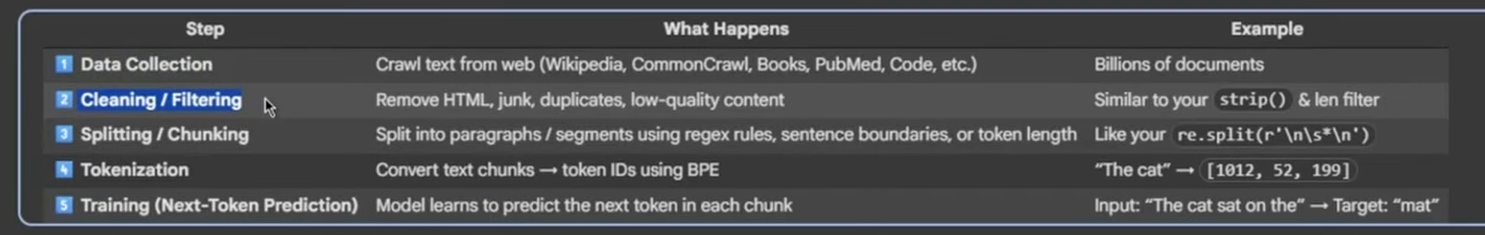

# ***CHUNKING A TOY DATASET***

In [ ]:
raw_document = """An Advanced Persistent Threat (APT) is a stealthy threat actor, typically a nation-state or state-sponsored group, which gains unauthorized access to a computer network and remains undetected for an extended period. Unlike automated malware, APTs are carefully orchestrated by human operators who actively adapt to the target's defenses.

The lifecycle of an APT attack typically involves several distinct phases: initial compromise, escalation of privileges, internal reconnaissance, lateral movement, and data exfiltration. Attackers often use spear-phishing emails or exploit zero-day vulnerabilities to establish their initial foothold before moving deeper into the network.

To defend against APTs, organizations must adopt a robust defense-in-depth strategy. This requires moving away from perimeter-only security and implementing a Zero Trust Architecture. Continuous network monitoring, anomaly detection, and endpoint detection and response (EDR) systems are critical for identifying the subtle footprints left by these actors."""

In [ ]:
import json

def chunk_by_paragraph(text_document):
    paragraphs = text_document.strip().split('\n\n')
    training_dataset = []

    for para in paragraphs:
        clean_para = para.replace('\n', ' ').strip()
        formatted_line = {
            "text": f"{clean_para} </s>"
        }
        training_dataset.append(formatted_line)

    return training_dataset

chunked_data = chunk_by_paragraph(raw_document)

with open("apt_domain_training.jsonl", "w") as f:
    for item in chunked_data:
        f.write(json.dumps(item) + "\n")
        print(json.dumps(item))

In [ ]:
from datasets import Dataset, load_dataset
dataset = Dataset.from_list(chunked_data)

In [ ]:
dataset

## Select Model


In [ ]:
# Base Model(Simple pre trained model)
model_name = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, DataCollatorForLanguageModeling

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
if tokeizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

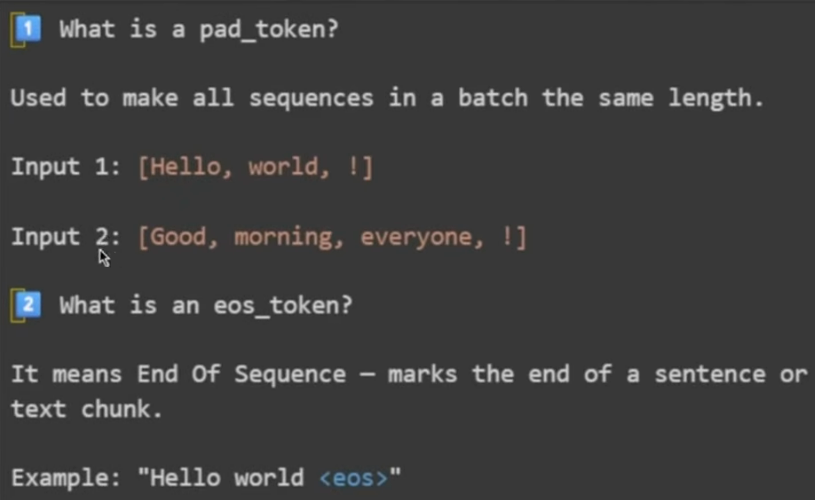

In [ ]:
def tokenize_fn(examples):
  tokens = tokenizer(examples["text"], truncation=True, padding="max_length",max_length=512)
  tokens["labels"] = tokens["input_ids"].copy()
  return tokens

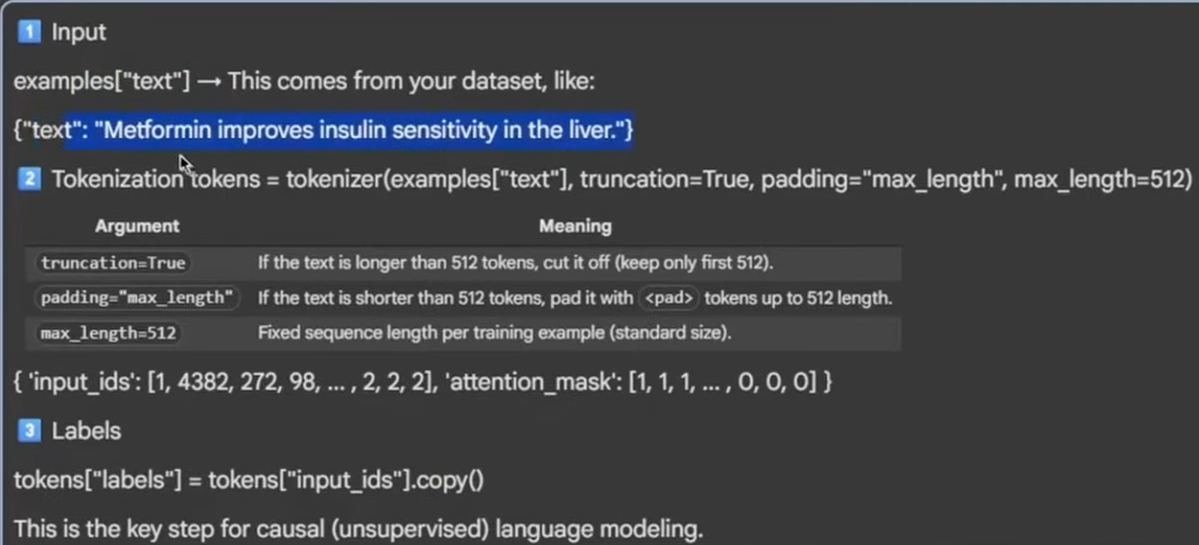

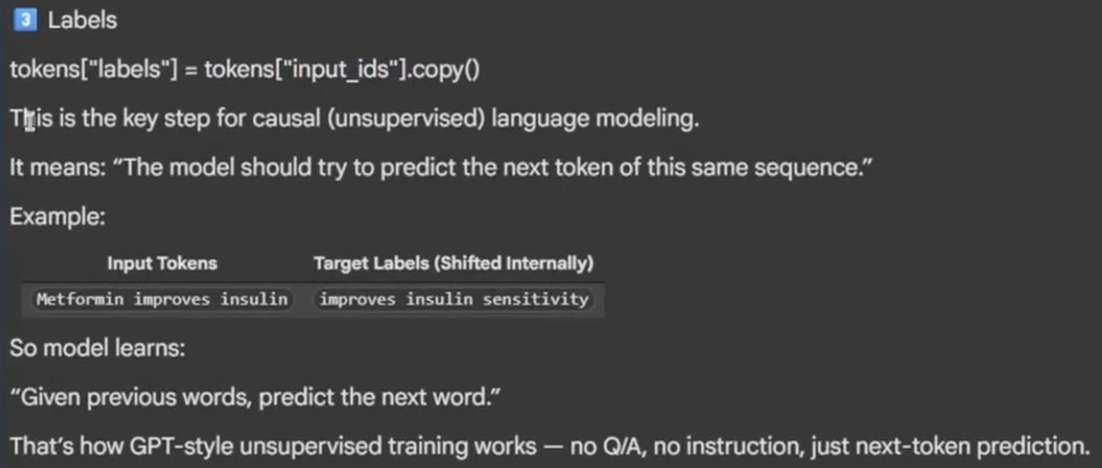

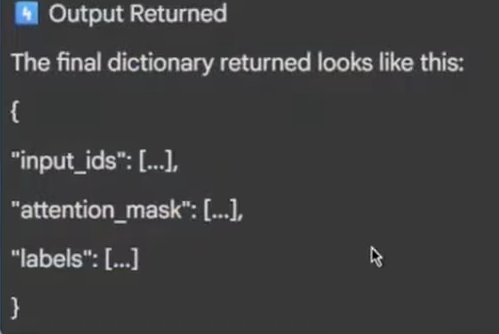

In [ ]:
tokenized = dataset.map(tokenize_fn, batched = True, remove_columns=["text"])

In [ ]:
tokenized

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_name)

In [ ]:
from transformers import Trainer, TrainingArguments
help(TrainingArguments)

In [ ]:
training_args = TrainingArguments(
    output_dir="./llama-security-domain",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    save_steps=500,
    save_total_limit=2,
    logging_steps=50,
    learning_rate=2e-5,
    fp16=True,
    report_to="none"
)

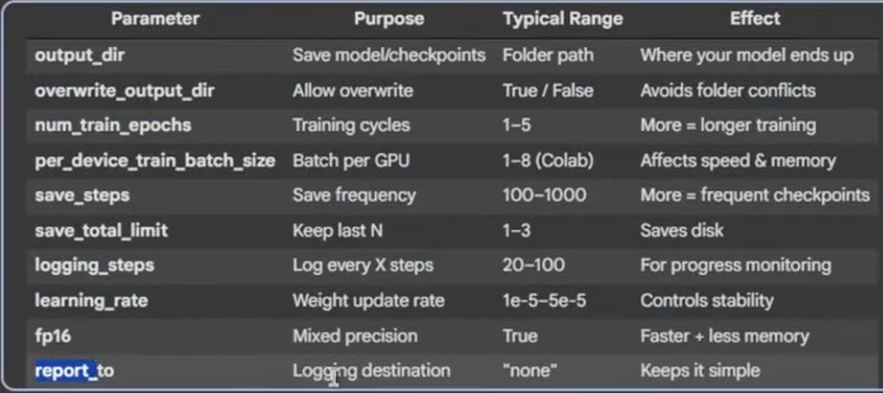

In [ ]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = tokenized
)

In [ ]:
trainer.train()

Here we are not specifying something means we are doing full fine tuning
# We got 2 methods for Partial finetuning


*   Freeze some layer and fine tune the unfreezed layer like we do in cnn(not appropriate method there are some pros and cons, not efficient  to larger llm's)
*   LORA(append some external weight to pretrained)



# IMPLEMENT LORA

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:

from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

In [ ]:
model = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model)

In [ ]:
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

In [ ]:
def tokenize_fn(examples):
  tokens = tokenizer(examples["text"], truncation=True, padding="max_length",max_length=512)
  tokens["labels"] = tokens["input_ids"].copy()
  return tokens

In [ ]:
tokenized = dataset.map(tokenize_fn, batched = True)

In [ ]:
tokenized

In [ ]:
from transformers import BitsAndBytesConfig

# loaded quantised model
quantization_config = BitsAndBytesConfig(load_in_8bit=True)
model = AutoModelForCausalLM.from_pretrained(
    model,
    quantization_config=quantization_config,
    device_map = "auto"
)

In [ ]:
model

In [ ]:

lora_config = LoraConfig(
    task_type = TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

In [ ]:
q_lora_model = get_peft_model(model,lora_config)

In [ ]:

training_args = TrainingArguments(
    output_dir="./llama-security-domain",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    save_steps=500,
    save_total_limit=2,
    logging_steps=50,
    learning_rate=2e-5,
    dataloader_pin_memory=False,
    fp16=True,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model = q_lora_model,
    args = training_args,
    train_dataset = tokenized
)

In [ ]:
!pip install -U accelerate

In [ ]:
trainer.train()

In [ ]:
model_path= "/content/llama-security-domain/checkpoint-4"

In [ ]:
trained_model = AutoModelForCausalLM.from_pretrained(model_path, device_map = "auto")

In [ ]:
prompt = "Phases of lifecycle of API attacks"

In [ ]:
inputs= tokenizer(prompt, return_tensors = "pt").to("cuda")

In [ ]:
outputs = trained_model.generate(
    **inputs,
    max_new_tokens = 100,
    temperature = 0.8,
    top_p = 0.9,
    do_sample = True,
    repetition_penalty = 1.1
)

In [ ]:
print("\n Model Output: \n")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))